# Rule Types


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

file_path = "/Users/RaulPerez/Documents/Projects/cumulative_report/data/raw/country_year_final_panel_full_new.csv"
df = pd.read_csv(file_path)

rule_prefixes = (
    "C_", "I_", "P_",
    "IM_", "GOV_", "PRESS_",
    "APPEAL_", "EXEMPTION_", "LAWSUIT", "REG_"
)

value_cols = [c for c in df.columns if str(c).startswith(rule_prefixes)]

id_cols = [c for c in df.columns if c in ["COUNTRY", "year", "iso3"] or str(c).startswith("Unnamed")]

X_presence = (df[value_cols].fillna(0) != 0).astype(int)

# Use the _new panel's authoritative weighted measures under the old
# analysis column names so the existing EDA code runs unchanged.
weighted_aliases = {
    "de_jure": "dj_expression",
    "weighted_de_jure": "wdj_expression",
    "weighted_de_jure_C": "wdj_citizen",
    "weighted_de_jure_I": "wdj_intermediaries",
    "weighted_de_jure_P": "wdj_press",
    "weighted_de_jure_GOV.PROT": "wdj_govprot",
    "weighted_de_jure_RESTRICTION": "wdj_restriction",
    "weighted_de_jure_OBLIGATION": "wdj_obligation",
}

for target, source in weighted_aliases.items():
    if target not in df.columns and source in df.columns:
        df[target] = df[source]

if "legal_rule_count_total" not in df.columns:
    df["legal_rule_count_total"] = X_presence.sum(axis=1)

if "legal_rule_count_RESTRICTION" not in df.columns:
    restriction_cols = [c for c in value_cols if "_EXPRESS_" in c]
    df["legal_rule_count_RESTRICTION"] = X_presence[restriction_cols].sum(axis=1)

if "legal_rule_count_OBLIGATION" not in df.columns:
    obligation_cols = [
        c for c in value_cols
        if c.startswith(("IM_", "GOV_", "PRESS_", "APPEAL_", "EXEMPTION_", "LAWSUIT", "REG_"))
    ]
    df["legal_rule_count_OBLIGATION"] = X_presence[obligation_cols].sum(axis=1)


print("Dataset shape:", df.shape)
print("Number of rule columns:", len(value_cols))
print("First 10 rule columns:", value_cols[:10])

Dataset shape: (8580, 753)
Number of rule columns: 730
First 10 rule columns: ['C_DISINFO_GEN', 'I_DISINFO_GEN', 'P_DISINFO_GEN', 'C_DISINFO_GEN_DIGI', 'I_DISINFO_GEN_DIGI', 'P_DISINFO_GEN_DIGI', 'C_DISINFO_GEN_CRISIS', 'I_DISINFO_GEN_CRISIS', 'P_DISINFO_GEN_CRISIS', 'C_MALINFO_GEN']


## Restriction and Obligation Column Groups


In [2]:
press_cols = [c for c in value_cols if c.startswith("P_")]
internet_cols = [c for c in value_cols if c.startswith("I_")]
press_gov_cols = [c for c in value_cols if c.startswith("PRESS_")]
im_cols = [c for c in value_cols if c.startswith("IM_")]

print("Press columns:", len(press_cols))
print("Internet/platform columns:", len(internet_cols))
print("Press governance columns:", len(press_gov_cols))
print("Intermediary governance columns:", len(im_cols))


Press columns: 225
Internet/platform columns: 225
Press governance columns: 10
Intermediary governance columns: 22


## Restrictions and Obligations by Actor


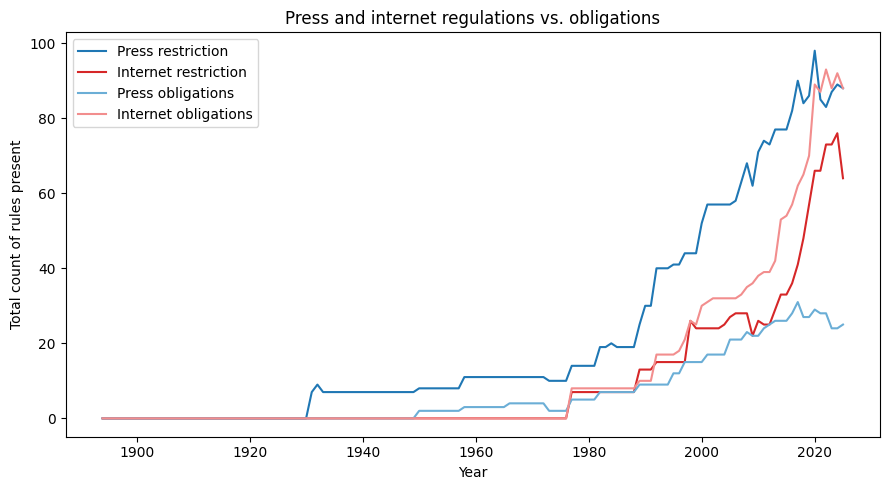

In [3]:
yearly_family_counts = pd.DataFrame({
    "year": df["year"],
    "P_total": X_presence[press_cols].sum(axis=1),
    "I_total": X_presence[internet_cols].sum(axis=1),
    "PRESS_total": X_presence[press_gov_cols].sum(axis=1),
    "IM_total": X_presence[im_cols].sum(axis=1)
})

yearly_family_counts = (
    yearly_family_counts.groupby("year")[["P_total", "I_total", "PRESS_total", "IM_total"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(9, 5))
plt.plot(
    yearly_family_counts["year"],
    yearly_family_counts["P_total"],
    label="Press restriction",
    color="#1f77b4"
)
plt.plot(
    yearly_family_counts["year"],
    yearly_family_counts["I_total"],
    label="Internet restriction",
    color="#d62728"
)
plt.plot(
    yearly_family_counts["year"],
    yearly_family_counts["PRESS_total"],
    label="Press obligations",
    color="#6baed6"
)
plt.plot(
    yearly_family_counts["year"],
    yearly_family_counts["IM_total"],
    label="Internet obligations",
    color="#f28e8e"
)
plt.xlabel("Year")
plt.ylabel("Total count of rules present")
plt.title("Press and internet regulations vs. obligations")
plt.legend()
plt.tight_layout()
plt.show()

## Restriction vs Obligation Scores


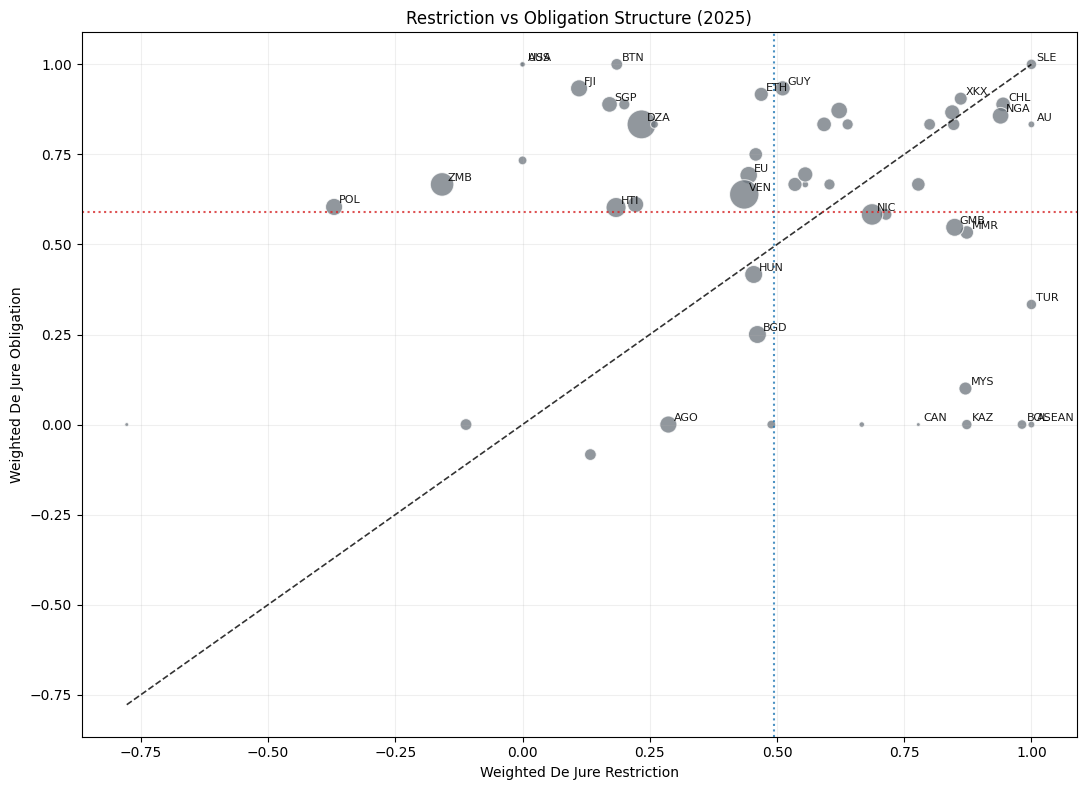

,COUNTRY,iso3,weighted_de_jure_RESTRICTION,weighted_de_jure_OBLIGATION,legal_rule_count_total,bubble_size,balance_gap
8183,Venezuela,VEN,0.435673,0.638889,56,448,0.203216
395,Algeria,DZA,0.233796,0.833333,54,432,0.599537
8447,Zambia,ZMB,-0.158120,0.666667,36,288,0.824786
5147,Nicaragua,NIC,0.686869,0.583333,30,240,0.103535
3299,Haiti,HTI,0.183761,0.602564,26,208,0.418803
7523,The Gambia,GMB,0.849206,0.547619,21,168,0.301587
923,Bangladesh,BGD,0.461538,0.250000,21,168,0.211538
3563,Hungary,HUN,0.454248,0.416667,21,168,0.037582
2639,European Union,EU,0.444444,0.692308,20,160,0.247863
5939,Poland,POL,-0.370370,0.604167,19,152,0.974537


In [4]:
plot_year = 2025

structure_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "weighted_de_jure_RESTRICTION",
        "weighted_de_jure_OBLIGATION",
        "legal_rule_count_total"
    ]]
    .dropna()
    .copy()
)

structure_df = structure_df[
    (structure_df["weighted_de_jure_RESTRICTION"] != 0) |
    (structure_df["weighted_de_jure_OBLIGATION"] != 0)
].copy()

structure_df["bubble_size"] = structure_df["legal_rule_count_total"] * 8
structure_df["balance_gap"] = (
    structure_df["weighted_de_jure_OBLIGATION"] - structure_df["weighted_de_jure_RESTRICTION"]
).abs()

label_df = pd.concat([
    structure_df.nlargest(12, "legal_rule_count_total"),
    structure_df.nlargest(10, "balance_gap"),
    structure_df.nlargest(10, "weighted_de_jure_RESTRICTION"),
    structure_df.nlargest(10, "weighted_de_jure_OBLIGATION")
]).drop_duplicates(subset="iso3")

x_mean = structure_df["weighted_de_jure_RESTRICTION"].mean()
y_mean = structure_df["weighted_de_jure_OBLIGATION"].mean()
line_min = min(
    structure_df["weighted_de_jure_RESTRICTION"].min(),
    structure_df["weighted_de_jure_OBLIGATION"].min()
)
line_max = max(
    structure_df["weighted_de_jure_RESTRICTION"].max(),
    structure_df["weighted_de_jure_OBLIGATION"].max()
)

plt.figure(figsize=(11, 8))
plt.scatter(
    structure_df["weighted_de_jure_RESTRICTION"],
    structure_df["weighted_de_jure_OBLIGATION"],
    s=structure_df["bubble_size"],
    color="#6c757d",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.8
)

for _, row in label_df.iterrows():
    plt.text(
        row["weighted_de_jure_RESTRICTION"] + 0.01,
        row["weighted_de_jure_OBLIGATION"] + 0.01,
        row["iso3"],
        fontsize=8,
        alpha=0.9
    )

plt.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle="--",
    color="black",
    linewidth=1.2,
    alpha=0.8
)
plt.axvline(x_mean, linestyle=":", color="#1f77b4", alpha=0.8)
plt.axhline(y_mean, linestyle=":", color="#d62728", alpha=0.8)

plt.xlabel("Weighted De Jure Restriction")
plt.ylabel("Weighted De Jure Obligation")
plt.title(f"Restriction vs Obligation Structure ({plot_year})")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

structure_df.sort_values("legal_rule_count_total", ascending=False)

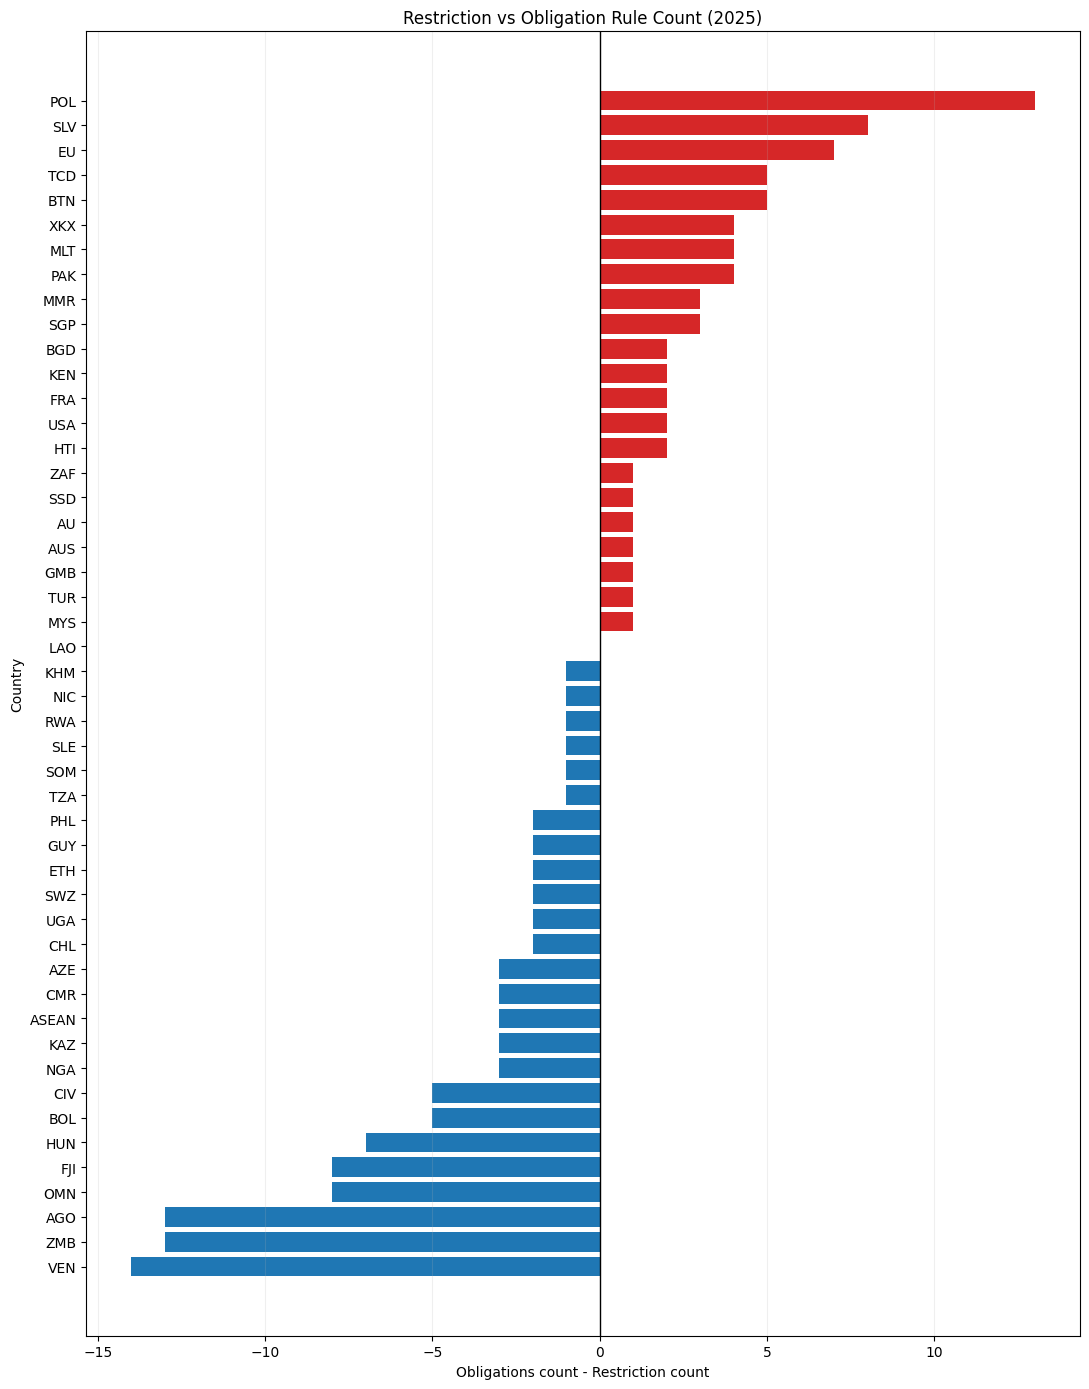

,COUNTRY,iso3,legal_rule_count_RESTRICTION,legal_rule_count_OBLIGATION,divergence,legal_rule_count_total
0,Venezuela,VEN,32,18,-14,56
1,Zambia,ZMB,23,10,-13,36
2,Angola,AGO,13,0,-13,19
3,Oman,OMN,9,1,-8,12
4,Fiji,FJI,13,5,-8,19
5,Hungary,HUN,11,4,-7,21
6,Bolivia,BOL,5,0,-5,6
7,"Côte d""Ivoire",CIV,7,2,-5,10
8,Nigeria,NGA,10,7,-3,18
9,Kazakhstan,KAZ,3,0,-3,7


In [5]:
plot_year = 2025

divergence_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "legal_rule_count_RESTRICTION",
        "legal_rule_count_OBLIGATION",
        "legal_rule_count_total"
    ]]
    .dropna()
    .copy()
)

divergence_df = divergence_df[
    (divergence_df["legal_rule_count_RESTRICTION"] != 0) |
    (divergence_df["legal_rule_count_OBLIGATION"] != 0)
].copy()

divergence_df = divergence_df[divergence_df["iso3"] != "DZA"].copy()

divergence_df["divergence"] = (
    divergence_df["legal_rule_count_OBLIGATION"] - divergence_df["legal_rule_count_RESTRICTION"]
)
divergence_df = divergence_df.sort_values("divergence").reset_index(drop=True)
divergence_df["bar_color"] = np.where(
    divergence_df["divergence"] >= 0,
    "#d62728",
    "#1f77b4"
)

plt.figure(figsize=(11, 14))
plt.barh(
    divergence_df["iso3"],
    divergence_df["divergence"],
    color=divergence_df["bar_color"]
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Obligations count - Restriction count")
plt.ylabel("Country")
plt.title(f"Restriction vs Obligation Rule Count ({plot_year})")
plt.grid(True, axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

divergence_df[["COUNTRY", "iso3", "legal_rule_count_RESTRICTION", "legal_rule_count_OBLIGATION", "divergence", "legal_rule_count_total"]]